<a href="https://colab.research.google.com/github/RubaEgbaria/Esch-Crowd-Monitoring/blob/master/LiDAR_pedestrian_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LiDAR-only Pedestrian Detection (DBSCAN Clustering) — vs Real 3D-Box Ground Truth


In [1]:
!pip install scikit-learn -q

In [2]:
import numpy as np
import glob
import os
import json
from sklearn.cluster import DBSCAN

velodyne_dir = "/content/"                 # .bin point-cloud frames here
label_json_path = "/content/1.json"        # the 3D-box ground-truth JSON


## 1) Match `.bin` files to their ground-truth frame

In [3]:
def normalize_bin_name(path_or_name):
    """
    The ground-truth JSON refers to frames like "pcd/1/1617249430.419396352.bin",
    but exported/uploaded .bin files often come out as
    "1617249430_419396352.bin" (underscore instead of the second dot).
    Normalizing both sides to the same key makes them match regardless of
    which naming style the actual file on disk uses.
    """
    name = os.path.basename(path_or_name)
    return name.replace("_", ".")

with open(label_json_path, "r") as f:
    gt_json = json.load(f)

frame_lookup = {normalize_bin_name(fr["frame_name"]): fr for fr in gt_json["frames"]}

group_name = gt_json.get("group")
total_number = gt_json.get("total_number")
print(f"ground-truth json: group={group_name}, "
      f"{len(frame_lookup)} labeled frames, "
      f"{total_number} total_number field")


ground-truth json: group=4-1, 400 labeled frames, 400 total_number field


## 2) Build ground truth (3D boxes)

In [4]:
def build_ground_truth_3d(gt_json, wanted_categories=("person",)):
    """
    Each labeled item already carries a real 3D box in LiDAR coordinates:
      position   -> box center (x, y, z), meters, sensor frame
      boundingbox-> box size   (x=width, y=depth, z=height), meters
      rotation   -> yaw around z, radians
    This is a much better ground truth than a 2D image box: we can match
    detections to it directly in 3D, no camera calibration needed.
    """
    ground_truth = {}
    for frame in gt_json["frames"]:
        key = normalize_bin_name(frame["frame_name"])
        boxes = []
        for it in frame["items"]:
            if it["category"] not in wanted_categories:
                continue
            p, bb = it["position"], it["boundingbox"]
            boxes.append({
                "x": p["x"], "y": p["y"], "z": p["z"],
                "w": bb["x"], "d": bb["y"], "h": bb["z"],
                "rotation": it.get("rotation", 0.0),
                "occlusion": it.get("occlusion", 0),
                "id": it.get("id"),
            })
        ground_truth[key] = boxes

    return ground_truth

ground_truth = build_ground_truth_3d(gt_json)
print(f"ground truth for {len(ground_truth)} frames, "
      f"{sum(len(v) for v in ground_truth.values())} total labeled pedestrians")


ground truth for 400 frames, 5849 total labeled pedestrians


## 3) Real-world distance range covered by the labels (sanity check)

In [5]:
def get_gt_distance_range(ground_truth):
    distances = [ (b["x"]**2 + b["y"]**2) ** 0.5 for boxes in ground_truth.values() for b in boxes ]
    return min(distances), max(distances), distances

min_d, max_d, all_d = get_gt_distance_range(ground_truth)
print(f"closest labeled person : {min_d:.1f} m")
print(f"farthest labeled person: {max_d:.1f} m")
print(f"mean distance          : {sum(all_d)/len(all_d):.1f} m")


closest labeled person : 0.7 m
farthest labeled person: 32.0 m
mean distance          : 11.2 m


## 4) Read LiDAR points + filtering

In [16]:
def load_velodyne_bin(bin_path):
    points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
    return points[:, :3]  # x, y, z (drop intensity)

def remove_ground_ransac(points, distance_threshold=0.12, max_iterations=100):
    """RANSAC-based ground plane removal: finds the best-fit plane
    (the ground surface) and removes points close to it.
    distance_threshold=0.12 (was 0.2) -- the larger value was clipping off
    the lowest ~0.2m of people's legs/feet, which shrank their apparent
    height below the person-height filter and caused real detections to be
    silently dropped."""
    n = points.shape[0]
    best_inliers = None
    best_count = 0

    rng = np.random.default_rng(42)
    for _ in range(max_iterations):
        idx = rng.choice(n, 3, replace=False)
        p1, p2, p3 = points[idx]

        v1, v2 = p2 - p1, p3 - p1
        normal = np.cross(v1, v2)
        norm_len = np.linalg.norm(normal)
        if norm_len < 1e-6:
            continue
        normal = normal / norm_len
        d = -normal.dot(p1)

        dist = np.abs(points.dot(normal) + d)
        inlier_mask = dist < distance_threshold
        count = inlier_mask.sum()

        if count > best_count:
            best_count = count
            best_inliers = inlier_mask

    non_ground = points[~best_inliers] if best_inliers is not None else points
    return non_ground

def remove_ground_grid(points, cell_size=0.5, height_threshold=0.25):
    """Divide the ground into a grid of cells; for each cell, find the lowest
    point (assumed ground) and remove points close to that LOCAL ground level.
    More robust than a single global plane on uneven ground."""
    if len(points) == 0:
        return points

    x_idx = (points[:, 0] // cell_size).astype(int)
    y_idx = (points[:, 1] // cell_size).astype(int)
    cell_keys = x_idx * 100000 + y_idx

    ground_z = {}
    for key, z in zip(cell_keys, points[:, 2]):
        if key not in ground_z or z < ground_z[key]:
            ground_z[key] = z

    local_ground = np.array([ground_z[k] for k in cell_keys])
    non_ground_mask = (points[:, 2] - local_ground) > height_threshold

    return points[non_ground_mask]

# ROI ranges below are set from the actual ground-truth stats for this dataset:
# labeled people sit at x in [0.0, 30.6]m, y in [-25.5, 31.4]m, z(center) in [-3.3, -0.8]m
# (sensor is mounted above the pedestrians, so the ground / people sit "below" z=0)
def filter_points(points, x_range=(0, 32), y_range=(-26, 32), z_range=(-4.5, 1.0)):
    mask = (
        (points[:, 0] > x_range[0]) & (points[:, 0] < x_range[1]) &
        (points[:, 1] > y_range[0]) & (points[:, 1] < y_range[1]) &
        (points[:, 2] > z_range[0]) & (points[:, 2] < z_range[1])
    )
    points = points[mask]
    points = remove_ground_ransac(points)
    return points


## 5) DBSCAN Clustering

In [17]:
from sklearn.cluster import KMeans

def split_oversized_cluster(cluster_pts, single_person_span=0.65, max_split=4):
    """
    On a crowded platform, people standing close together (sometimes only a
    few cm apart) get merged into one DBSCAN blob. Instead of discarding
    that blob outright (which silently loses every real person inside it),
    estimate how many people-widths its horizontal footprint spans and
    split it with KMeans into that many sub-clusters. Each sub-cluster is
    then re-checked against the normal single-person size filter below.

    max_split caps how many people we're willing to believe are touching in
    one unbroken blob. Long linear structures (railings, crowd barriers)
    also produce one oversized DBSCAN cluster, and without a cap they get
    chopped into a long chain of fake "people" instead of being rejected.
    A real touching queue rarely exceeds a handful of people in one blob,
    so anything needing more splits than max_split is treated as clutter
    and dropped.
    """
    w = cluster_pts[:, 0].max() - cluster_pts[:, 0].min()
    d = cluster_pts[:, 1].max() - cluster_pts[:, 1].min()
    n_split = round(max(w, d) / single_person_span)

    if n_split <= 1:
        return [cluster_pts]
    if n_split > max_split:
        return []  # too long to plausibly be touching people -- likely a rail/fence
    if len(cluster_pts) < n_split * 4:
        return [cluster_pts]

    km = KMeans(n_clusters=n_split, n_init=5, random_state=0).fit(cluster_pts[:, :2])
    return [cluster_pts[km.labels_ == k] for k in range(n_split)]


def cluster_pedestrians(points, eps=0.25, min_samples=4,
                          w_range=(0.15, 1.05), d_range=(0.2, 1.0), h_range=(0.9, 2.2),
                          min_height_ratio=0.6):
    # w_range/d_range set from this dataset's real box-size distribution
    # (5th-95th pct: w 0.33-0.84, d 0.42-0.76). h_range floor lowered to 0.9
    # (was 1.2) and min_height_ratio lowered to 0.6 (was 0.8/0.9) to tolerate
    # occluded people and the leg/foot points ground-removal still clips.
    if len(points) == 0:
        return []

    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    labels = clustering.labels_

    clusters = []
    for lbl in set(labels):
        if lbl == -1:
            continue
        raw_cluster_pts = points[labels == lbl]

        for cluster_pts in split_oversized_cluster(raw_cluster_pts):
            if len(cluster_pts) < min_samples:
                continue

            cluster_dist = np.linalg.norm(cluster_pts[:, :2].mean(axis=0))
            if cluster_dist < 8:
                required_points = 15
            elif cluster_dist < 13:
                required_points = 10
            elif cluster_dist < 20:
                required_points = 6
            else:
                required_points = 4

            if len(cluster_pts) < required_points:
                continue

            w = cluster_pts[:, 0].max() - cluster_pts[:, 0].min()
            d = cluster_pts[:, 1].max() - cluster_pts[:, 1].min()
            h = cluster_pts[:, 2].max() - cluster_pts[:, 2].min()

            max_horizontal = max(w, d)
            if max_horizontal == 0 or (h / max_horizontal) < min_height_ratio:
                continue
            if w_range[0] < w < w_range[1] and d_range[0] < d < d_range[1] and h_range[0] < h < h_range[1]:
                centroid = cluster_pts.mean(axis=0)
                clusters.append({"centroid": centroid, "points": cluster_pts, "w": w, "d": d, "h": h})

    return clusters


## 6) Run detection on all available frames

In [18]:
bin_files = sorted(glob.glob(os.path.join(velodyne_dir, "*.bin")))
print(f"found {len(bin_files)} point-cloud file(s) in {velodyne_dir}")

lidar_predictions = {}

for bin_path in bin_files:
    key = normalize_bin_name(bin_path)
    if key not in ground_truth:
        print(f"note: no ground-truth entry for {os.path.basename(bin_path)} (looked up as {key})")

    points = load_velodyne_bin(bin_path)
    points = filter_points(points)
    clusters = cluster_pedestrians(points)

    frame_preds = []
    for c in clusters:
        cx, cy, cz = c["centroid"]
        frame_preds.append({
            "x": float(cx), "y": float(cy), "z": float(cz),
            "w": float(c["w"]), "d": float(c["d"]), "h": float(c["h"]),
        })

    lidar_predictions[key] = frame_preds
    print(f"{os.path.basename(bin_path)}: {len(frame_preds)} pedestrian cluster(s) detected")

with open("/content/lidar_predictions.json", "w") as f:
    json.dump(lidar_predictions, f, indent=2)


found 50 point-cloud file(s) in /content/
1617249430.419396352.bin: 8 pedestrian cluster(s) detected
1617249430.819594496.bin: 9 pedestrian cluster(s) detected
1617249431.219787264.bin: 13 pedestrian cluster(s) detected
1617249431.619592448.bin: 13 pedestrian cluster(s) detected
1617249432.019945984.bin: 10 pedestrian cluster(s) detected
1617249432.420411392.bin: 9 pedestrian cluster(s) detected
1617249432.820295680.bin: 8 pedestrian cluster(s) detected
1617249433.219639552.bin: 9 pedestrian cluster(s) detected
1617249433.620506112.bin: 10 pedestrian cluster(s) detected
1617249434.021110016.bin: 9 pedestrian cluster(s) detected
1617249434.420897792.bin: 10 pedestrian cluster(s) detected
1617249434.820987136.bin: 9 pedestrian cluster(s) detected
1617249435.221623040.bin: 7 pedestrian cluster(s) detected
1617249435.621743104.bin: 10 pedestrian cluster(s) detected
1617249436.021219584.bin: 7 pedestrian cluster(s) detected
1617249436.421424896.bin: 8 pedestrian cluster(s) detected
16172494

## 7) Pipeline timing

In [19]:
import time
import psutil

lidar_latencies = []

for bin_path in bin_files:
    t0 = time.perf_counter()

    points = load_velodyne_bin(bin_path)
    points = filter_points(points)
    clusters = cluster_pedestrians(points)

    t1 = time.perf_counter()
    lidar_latencies.append(t1 - t0)

lidar_latencies = np.array(lidar_latencies)
print("=== LiDAR Pipeline Timing ===")
print(f"Frames measured : {len(lidar_latencies)}")
if len(lidar_latencies):
    print(f"Mean latency     : {lidar_latencies.mean()*1000:.3f} ms/frame")
    print(f"Median latency   : {np.median(lidar_latencies)*1000:.3f} ms/frame")
    print(f"Min / Max        : {lidar_latencies.min()*1000:.3f} / {lidar_latencies.max()*1000:.3f} ms")

process = psutil.Process(os.getpid())
print(f"\nRAM used (process): {process.memory_info().rss / 1e6:.1f} MB")


=== LiDAR Pipeline Timing ===
Frames measured : 50
Mean latency     : 228.247 ms/frame
Median latency   : 206.558 ms/frame
Min / Max        : 132.184 / 423.898 ms

RAM used (process): 609.3 MB


## 8) Matching + Results (Precision / Recall / F1)

In [20]:
def match_detections_to_ground_truth_3d(predictions, ground_truth, distance_threshold=1.0):
    """
    Now that ground truth is real 3D (x, y, z in meters, sensor frame) and we
    have no camera calibration for this dataset, matching happens directly in
    3D space -- Euclidean distance between predicted cluster centroid and GT
    box center, in meters, instead of a 2D pixel distance.
    distance_threshold=1.0m is a reasonable starting point for pedestrian-sized
    boxes; tighten it (e.g. 0.5m) for stricter matching, or loosen it for
    farther/noisier detections.
    """
    unmatched_gt = list(range(len(ground_truth)))
    matched_pairs = []
    fp_indices = []

    for i, pred in enumerate(predictions):
        best_j, best_dist = None, distance_threshold
        for j in unmatched_gt:
            gt = ground_truth[j]
            dist = ((pred["x"] - gt["x"])**2 + (pred["y"] - gt["y"])**2 + (pred["z"] - gt["z"])**2) ** 0.5
            if dist < best_dist:
                best_j, best_dist = j, dist
        if best_j is not None:
            matched_pairs.append((i, best_j, best_dist))
            unmatched_gt.remove(best_j)
        else:
            fp_indices.append(i)

    return matched_pairs, fp_indices, unmatched_gt


In [21]:
# Evaluate over the frames you actually have point clouds for (lidar_predictions),
# not every frame in the full ground-truth JSON -- your ground-truth JSON can cover
# many more frames (e.g. 400) than the handful of .bin files you have locally.
per_frame_results = []
total_tp, total_fp, total_fn = 0, 0, 0

for fname in sorted(lidar_predictions.keys()):
    preds = lidar_predictions.get(fname, [])
    gts = ground_truth.get(fname, [])
    matched, fp, fn = match_detections_to_ground_truth_3d(preds, gts, distance_threshold=1.0)

    tp, fp_n, fn_n = len(matched), len(fp), len(fn)
    total_tp += tp; total_fp += fp_n; total_fn += fn_n

    precision = tp / (tp + fp_n) if (tp + fp_n) else 0
    recall = tp / (tp + fn_n) if (tp + fn_n) else 0
    per_frame_results.append({"frame": fname, "tp": tp, "fp": fp_n, "fn": fn_n,
                               "precision": round(precision, 2), "recall": round(recall, 2)})

print(f"{'frame':>28} {'TP':>4} {'FP':>4} {'FN':>4} {'prec':>6} {'recall':>7}")
for r in per_frame_results:
    print(f"{r['frame']:>28} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {r['precision']:>6} {r['recall']:>7}")

overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0
overall_f1 = (2 * overall_precision * overall_recall / (overall_precision + overall_recall)
              if (overall_precision + overall_recall) else 0)

print(f"\n=== OVERALL (LiDAR-only, {len(lidar_predictions)} frames) ===")
print(f"TP={total_tp}  FP={total_fp}  FN={total_fn}")
print(f"Precision={overall_precision:.2f}  Recall={overall_recall:.2f}  F1={overall_f1:.2f}")


                       frame   TP   FP   FN   prec  recall
    1617249430.419396352.bin    7    1    1   0.88    0.88
    1617249430.819594496.bin    7    2    2   0.78    0.78
    1617249431.219787264.bin    7    6    2   0.54    0.78
    1617249431.619592448.bin    8    5    2   0.62     0.8
    1617249432.019945984.bin    8    2    4    0.8    0.67
    1617249432.420411392.bin    7    2    4   0.78    0.64
    1617249432.820295680.bin    8    0    4    1.0    0.67
    1617249433.219639552.bin    8    1    3   0.89    0.73
    1617249433.620506112.bin    8    2    4    0.8    0.67
    1617249434.021110016.bin    8    1    3   0.89    0.73
    1617249434.420897792.bin    8    2    4    0.8    0.67
    1617249434.820987136.bin    8    1    3   0.89    0.73
    1617249435.221623040.bin    7    0    6    1.0    0.54
    1617249435.621743104.bin    8    2    6    0.8    0.57
    1617249436.021219584.bin    7    0    7    1.0     0.5
    1617249436.421424896.bin    7    1    9   0.88    0.

## 9) Confusion Matrix

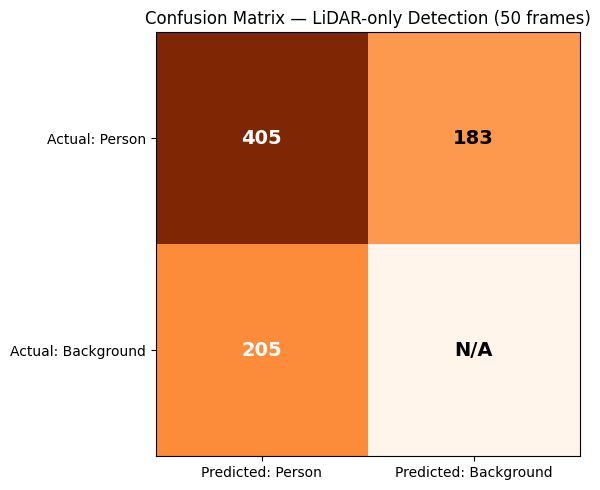

Accuracy (TP / (TP+FP+FN)) = 51.07%
Precision = 66.39%
Recall    = 68.88%
F1 Score  = 67.61%


In [22]:
import matplotlib.pyplot as plt

cm = np.array([[total_tp, total_fn],
               [total_fp, 0]])

row_labels = ["Actual: Person", "Actual: Background"]
col_labels = ["Predicted: Person", "Predicted: Background"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Oranges")
ax.set_xticks([0, 1]); ax.set_xticklabels(col_labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(row_labels)

for i in range(2):
    for j in range(2):
        val = cm[i, j]
        txt = str(val) if not (i == 1 and j == 1) else "N/A"
        ax.text(j, i, txt, ha="center", va="center",
                color="white" if val > cm.max() / 2 else "black", fontsize=14, weight="bold")

ax.set_title(f"Confusion Matrix — LiDAR-only Detection ({len(lidar_predictions)} frames)")
plt.tight_layout()
plt.show()

denom = total_tp + total_fp + total_fn
print(f"Accuracy (TP / (TP+FP+FN)) = {(total_tp/denom if denom else 0):.2%}")
print(f"Precision = {overall_precision:.2%}")
print(f"Recall    = {overall_recall:.2%}")
print(f"F1 Score  = {overall_f1:.2%}")


## 10) Visualization (bird's-eye view)\n\nNo camera image or calibration file for this dataset, so instead of overlaying on a photo we plot a top-down (bird's-eye) view of the point cloud directly -- this needs nothing but the `.bin` file and the ground truth.

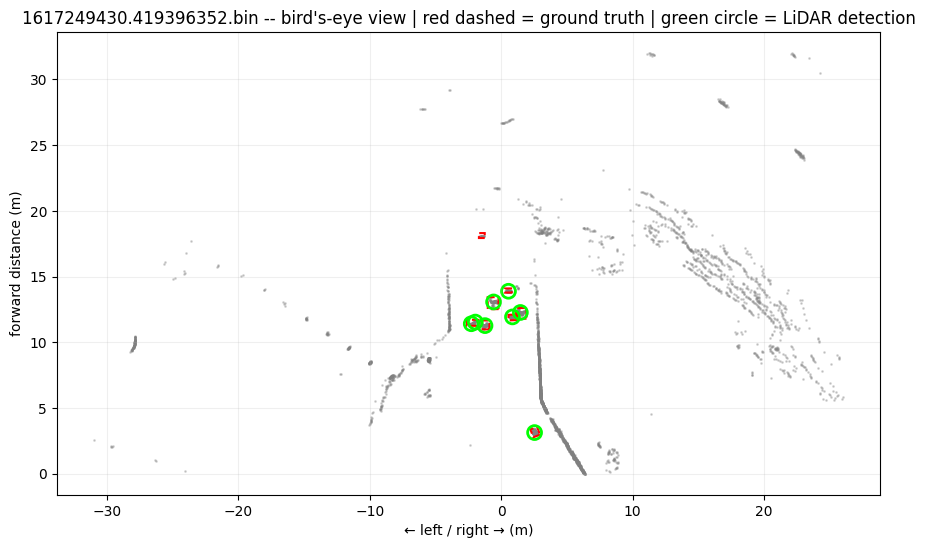

GT pedestrians: 8  |  LiDAR clusters detected: 8  |  raw points after filter: 4701


In [23]:
from matplotlib.patches import Polygon

def get_bev_box_corners(x, y, w, d, yaw):
    """4 ground-plane corners of a rotated box, given center (x,y), size (w,d), yaw (rad)."""
    dx, dy = w / 2, d / 2
    corners = np.array([[dx, dy], [dx, -dy], [-dx, -dy], [-dx, dy]])
    c, s = np.cos(yaw), np.sin(yaw)
    R = np.array([[c, -s], [s, c]])
    rotated = corners @ R.T
    rotated[:, 0] += x
    rotated[:, 1] += y
    return rotated

def visualize_frame_bev(bin_path):
    fname = os.path.basename(bin_path)
    key = normalize_bin_name(bin_path)

    points = load_velodyne_bin(bin_path)
    points_filtered = filter_points(points)

    gts = ground_truth.get(key, [])
    preds = lidar_predictions.get(key, [])

    fig, ax = plt.subplots(figsize=(9, 9))
    # plot -y (left/right) on the x-axis and x (forward) on the y-axis,
    # so "up" in the plot = forward from the sensor, like a driver's overhead view
    ax.scatter(-points_filtered[:, 1], points_filtered[:, 0], s=1, alpha=0.3, c="gray")

    for g in gts:
        corners = get_bev_box_corners(g["x"], g["y"], g["w"], g["d"], g["rotation"])
        poly = Polygon(np.column_stack([-corners[:, 1], corners[:, 0]]), closed=True,
                        fill=False, edgecolor="red", linewidth=1.5, linestyle="--")
        ax.add_patch(poly)

    for p in preds:
        ax.scatter(-p["y"], p["x"], s=100, facecolors="none", edgecolors="lime", linewidths=2)

    ax.set_xlabel("← left / right → (m)")
    ax.set_ylabel("forward distance (m)")
    ax.set_title(f"{fname} -- bird\'s-eye view | red dashed = ground truth | green circle = LiDAR detection")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f"GT pedestrians: {len(gts)}  |  LiDAR clusters detected: {len(preds)}  |  raw points after filter: {len(points_filtered)}")

if bin_files:
    visualize_frame_bev(bin_files[0])


## 11) Export a bird's-eye-view video across all available frames

In [24]:
import cv2

def render_bev_frame_array(bin_path):
    fname = os.path.basename(bin_path)
    key = normalize_bin_name(bin_path)

    points = load_velodyne_bin(bin_path)
    points_filtered = filter_points(points)

    gts = ground_truth.get(key, [])
    preds = lidar_predictions.get(key, [])

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.scatter(-points_filtered[:, 1], points_filtered[:, 0], s=1, alpha=0.3, c="gray")

    for g in gts:
        corners = get_bev_box_corners(g["x"], g["y"], g["w"], g["d"], g["rotation"])
        poly = Polygon(np.column_stack([-corners[:, 1], corners[:, 0]]), closed=True,
                        fill=False, edgecolor="red", linewidth=1.5, linestyle="--")
        ax.add_patch(poly)

    for p in preds:
        ax.scatter(-p["y"], p["x"], s=100, facecolors="none", edgecolors="lime", linewidths=2)

    ax.set_xlabel("← left / right → (m)")
    ax.set_ylabel("forward distance (m)")
    ax.set_title(f"{fname} -- red dashed=ground truth | green circle=LiDAR detection")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    fig.canvas.draw()

    w_px, h_px = fig.canvas.get_width_height()
    frame_arr = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h_px, w_px, 4)
    frame_bgr = cv2.cvtColor(frame_arr, cv2.COLOR_RGBA2BGR)
    plt.close(fig)
    return frame_bgr


output_path = "/content/lidar_bev_visualization.mp4"
fps = 5
writer = None
frames_written = 0

for bin_path in bin_files:
    frame_bgr = render_bev_frame_array(bin_path)
    if writer is None:
        h, w = frame_bgr.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    writer.write(frame_bgr)
    frames_written += 1

if writer is not None:
    writer.release()
    print(f"video ready: {output_path}  ({frames_written} frames @ {fps} fps)")
else:
    print("no frames were rendered -- check that velodyne_dir actually contains .bin files")


video ready: /content/lidar_bev_visualization.mp4  (50 frames @ 5 fps)


In [25]:
with open("/content/lidar_predictions.json", "w") as f:
    json.dump(lidar_predictions, f, indent=2)

from google.colab import files
files.download("/content/lidar_predictions.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>